In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

tobetm_traffic_feed_path = kagglehub.dataset_download('tobetm/traffic-feed')

print('Data source import complete.')


# Adaptive Traffic Light System — YOLO26 + PCE-Weighted Fuzzy Control

**Pipeline:** YOLO26-nano detection + ByteTrack tracking → PCE aggregation over a waiting-zone ROI → Mamdani fuzzy controller → adaptive green-phase duration.

**Target:** Low-power edge (Raspberry Pi / Jetson Nano) at a 2-lane intersection.

**Key Updates in this version:**
- Transitioned to Roboflow 'Indonesia Vehicle' dataset.
- **[NEW]** Automated Label Merging: Reduced 21 ambiguous classes into 4 MKJI 1997 super-classes to drastically boost mAP and Recall.
- Implemented Garbage Collection in the inference loop to prevent edge OOM (Out-Of-Memory) crashes.
- Stateful queue mathematics applied to the baseline comparison for accurate delay/oversaturation metrics.

In [ ]:
import os
os.environ['RAY_DISABLE_IMPORT_WARNING'] = '1'
os.environ['TUNE_DISABLE_AUTO_CALLBACK_LOGGERS'] = '1'
# Install pinned dependencies.
!pip install -q --upgrade ultralytics scikit-fuzzy "lap>=0.5.12" roboflow

# Verify packages are available
import ultralytics, skfuzzy, lap
print(f"ultralytics  : {ultralytics.__version__}")
print(f"scikit-fuzzy : {skfuzzy.__version__}")
print(f"lap          : OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 1.4 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.7 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependenc

In [ ]:
# --- Kaggle environment sanity check ---
# Catches the two most common Kaggle setup mistakes early with a clear message,
# instead of a confusing failure later inside roboflow or torch.cuda.
import torch
import socket

# 1. Internet check (Kaggle defaults to internet OFF; needed for pip installs + Roboflow download)
try:
    socket.create_connection(("8.8.8.8", 53), timeout=3)
    print("Internet: OK")
except OSError:
    raise RuntimeError(
        "No internet access detected. On Kaggle: open the right sidebar -> Settings -> "
        "Internet -> turn ON, then restart the session."
    )

# 2. GPU check (Kaggle defaults to GPU OFF/None; needed for model.train())
if torch.cuda.is_available():
    print(f"GPU: OK -> {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
else:
    raise RuntimeError(
        "No GPU detected. On Kaggle: open the right sidebar -> Settings -> Accelerator -> "
        "select GPU T4 x2 or GPU P100, then restart the session."
    )


Internet: OK
GPU: OK -> Tesla T4 (15.6 GB)


In [ ]:
# 1. Tarik dataset dari Roboflow (Indonesia Vehicle)
from roboflow import Roboflow
import os

# PASTIKAN API KEY ANDA BENAR DI SINI
rf = Roboflow(api_key="RjPf6XIfyszUlI4kHz76")
project = rf.workspace("arkhsat-project").project("indonesia-vehicle-ww6hv")
version = project.version(1)
dataset = version.download("yolov8")

# IMPORTANT: dataset.location is the SOURCE OF TRUTH for where files actually landed.
# Do not hardcode /content or /workspace anywhere downstream -- always reference DATASET_DIR.
DATASET_DIR = os.path.abspath(dataset.location)
print(f"Dataset downloaded to: {DATASET_DIR}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Indonesia-Vehicle-1 in yolov8:: 100%|██████████| 35733/35733 [00:05<00:00, 6807.57it/s] 


Dataset downloaded to: /kaggle/working/Indonesia-Vehicle-1


## Label Merging (Data Preprocessing)
To fix the low Recall (40%) and mAP (38%), we map the 21 hyper-specific classes into 4 standardized MKJI 1997 macro-classes. This prevents the model from confusing visually identical vehicles (e.g., car vs suv vs taxi) and balances the dataset.

In [ ]:
import os
import glob

# DATASET_DIR now comes from the Roboflow download cell above (dataset.location).
# This makes the notebook portable across Colab (/content), RunPod/cloud GPU pods (/workspace),
# and your own workstation, instead of assuming one fixed path.
assert "DATASET_DIR" in dir(), "Run the Roboflow download cell first so DATASET_DIR is defined."
print(f"Using dataset at: {DATASET_DIR}")

# Mapping 21 old class IDs to 4 new super-class IDs
# 0: light_vehicle, 1: heavy_vehicle, 2: two_wheeler, 3: unmotorized
CLASS_MAP = {
    0: 0,   # ambulance -> Light
    1: 1,   # army vehicle -> Heavy
    2: 3,   # auto rickshaw -> Unmotorized/Local
    3: 3,   # bicycle -> Unmotorized/Local
    4: 1,   # bus -> Heavy
    5: 0,   # car -> Light
    6: 1,   # garbagevan -> Heavy
    7: 3,   # human hauler -> Unmotorized/Local
    8: 1,   # minibus -> Heavy
    9: 0,   # minivan -> Light
    10: 2,  # motorbike -> Two-Wheeler
    11: 0,  # pickup -> Light
    12: 0,  # policecar -> Light
    13: 3,  # rickshaw -> Unmotorized/Local
    14: 2,  # scooter -> Two-Wheeler
    15: 0,  # suv -> Light
    16: 0,  # taxi -> Light
    17: 3,  # three wheelers -cng- -> Unmotorized/Local
    18: 1,  # truck -> Heavy
    19: 0,  # van -> Light
    20: 3   # wheelbarrow -> Unmotorized/Local
}

def merge_labels(label_dir):
    txt_files = glob.glob(os.path.join(label_dir, "*.txt"))
    for file_path in txt_files:
        with open(file_path, 'r') as file:
            lines = file.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) > 0:
                old_class_id = int(parts[0])
                if old_class_id in CLASS_MAP:
                    new_class_id = CLASS_MAP[old_class_id]
                    new_line = f"{new_class_id} " + " ".join(parts[1:]) + "\n"
                    new_lines.append(new_line)

        with open(file_path, 'w') as file:
            file.writelines(new_lines)

# Execute merging for both train and validation sets
merge_labels(os.path.join(DATASET_DIR, "train", "labels"))
merge_labels(os.path.join(DATASET_DIR, "valid", "labels"))

print("Label merging successfully completed! 21 classes reduced to 4 MKJI super-classes.")


Using dataset at: /kaggle/working/Indonesia-Vehicle-1
Label merging successfully completed! 21 classes reduced to 4 MKJI super-classes.


In [ ]:
import os

# Write data.yaml next to the dataset itself (not a fixed /content or /workspace path)
DATA_YAML_PATH = os.path.join(DATASET_DIR, 'data.yaml')

DATA_YAML = f"""
path: {DATASET_DIR}
train: train/images
val:   valid/images

names:
  0: light_vehicle
  1: heavy_vehicle
  2: two_wheeler
  3: unmotorized
"""

with open(DATA_YAML_PATH, 'w') as f:
    f.write(DATA_YAML)
print(f"Updated data.yaml written with 4 super-classes at: {DATA_YAML_PATH}")


Updated data.yaml written with 4 super-classes at: /kaggle/working/Indonesia-Vehicle-1/data.yaml


In [ ]:
# ── 4-Model Training Loop (Robust Save-Dir Tracking) ──────────────────────────
import os
os.environ['RAY_DISABLE_IMPORT_WARNING'] = '1'
os.environ['TUNE_DISABLE_AUTO_CALLBACK_LOGGERS'] = '1'
from ultralytics import YOLO
from ultralytics.utils import SETTINGS
SETTINGS['raytune'] = False

# Configuration updated to include YOLOv10n
MODELS_TO_TRAIN = [
    ('YOLOv8n',  'yolov8n.pt'),
    ('YOLOv10n', 'yolov10n.pt'),  # Added 4th Model
    ('YOLOv11n', 'yolo11n.pt'),
    ('YOLO26n',  'yolo26n.pt'),
]

TRAIN_KWARGS = dict(
    data=DATA_YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=32,
    device=[0, 1],
    amp=True,
    workers=8,
    cache='disk',
    optimizer='auto',
    patience=20,
    plots=True,
    close_mosaic=10,
    exist_ok=True,
    verbose=False,
)

train_results = {}

for model_label, weight in MODELS_TO_TRAIN:
    run_name = f'traffic_{model_label.lower()}'
    print(f"\n{'='*55}")
    print(f"  Training {model_label}  ({weight})  →  {run_name}")
    print(f"{'='*55}")
    model = YOLO(weight)
    res = model.train(**TRAIN_KWARGS, name=run_name)
    train_results[model_label] = res

    # ── Safe Multi-Version Directory Discovery ───────────────────────────────
    if res is not None and hasattr(res, 'save_dir'):
        save_dir = res.save_dir
    elif res is not None and isinstance(res, dict) and 'save_dir' in res:
        save_dir = res['save_dir']
    elif hasattr(model, 'trainer') and model.trainer is not None and hasattr(model.trainer, 'save_dir'):
        save_dir = model.trainer.save_dir
    else:
        save_dir = f"/kaggle/working/runs/detect/{run_name}"

    print(f"  ✓ {model_label} done — saved to {save_dir}")

print("\n✅ All 4 models trained.")


  Training YOLOv8n  (yolov8n.pt)  →  traffic_yolov8n
Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Indonesia-Vehicle-1/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mo

In [ ]:
# (This cell previously launched torchrun manually.
#  Training is now handled entirely in the cell above via model.train(device=[0,1]),
#  which sets up DDP internally — no separate subprocess needed.)
print("Training already completed in the loop above. Skipping torchrun cell.")


Training already completed in the loop above. Skipping torchrun cell.


In [ ]:
from ultralytics import YOLO
import os, glob

# ── Validate all 4 trained models and collect metrics ────────────────────────
MODELS_TO_EVAL = [
    ('YOLOv8n',  'traffic_yolov8n'),
    ('YOLOv10n', 'traffic_yolov10n'),  # Added 4th Model
    ('YOLOv11n', 'traffic_traffic_yolov11n' if os.path.exists('/kaggle/working/runs/detect/traffic_traffic_yolov11n') else 'traffic_yolov11n'),
    ('YOLO26n',  'traffic_yolo26n'),
]

comparison_results = {}   # label -> dict of metrics
trained_models     = {}   # label -> loaded YOLO object (reused later)

for model_label, run_name in MODELS_TO_EVAL:
    weights_path = f'/kaggle/working/runs/detect/{run_name}/weights/best.pt'

    # Graceful fallback: Ultralytics auto-increments folder names on re-runs
    if not os.path.isfile(weights_path):
        candidates = glob.glob(
            f'/kaggle/working/runs/detect/{run_name}*/weights/best.pt'
        )
        if candidates:
            weights_path = max(candidates, key=os.path.getmtime)
            print(f"[{model_label}] Using auto-discovered weights: {weights_path}")
        else:
            print(f"[{model_label}] ⚠️  No weights found — skipping.")
            continue

    model = YOLO(weights_path)
    metrics = model.val(data=DATA_YAML_PATH, split='val')

    p     = metrics.box.mp
    r     = metrics.box.mr
    m50   = metrics.box.map50
    m5095 = metrics.box.map
    f1    = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

    comparison_results[model_label] = {
        'Precision': round(p,     4),
        'Recall':    round(r,     4),
        'F1-Score':  round(f1,    4),
        'mAP@50':    round(m50,   4),
        'mAP@50:95': round(m5095, 4),
    }
    trained_models[model_label] = model
    print(f"  [{model_label}]  P={p:.4f}  R={r:.4f}  F1={f1:.4f}  mAP50={m50:.4f}")

print("\n✅ Validation complete for all available models.")

Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1559.3±574.3 MB/s, size: 78.6 KB)
val: Scanning /kaggle/working/Indonesia-Vehicle-1/valid/labels.cache... 2102 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2102/2102 678.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 264, len(boxes) = 2309. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 7.2it/s 18.4s0.1s
                   all       2102       2309      0.948      0.944       0.97      0.803
         light_vehicle        427        441      0.991      0.983      0.991      0.869
         heav

## Computer Vision Evaluation Metrics — 4-Model Comparison

We train and evaluate **YOLOv8n**, **YOLOv11n**, and **YOLO26n** on the same
MKJI 1997 4-class dataset to identify the best backbone for our adaptive
traffic light system. Metrics reported:

- **Precision (P):** Minimises false positives → avoids unnecessary green time.
- **Recall (R):** Minimises false negatives → critical for dense motorcycle occlusion in Indonesia.
- **F1-Score:** Harmonic mean of P and R — single balanced score.
- **mAP@50 / mAP@50:95:** Standard COCO detection benchmarks.


In [ ]:
import pandas as pd

# ── Print comparison table ───────────────────────────────────────────────────
if comparison_results:
    df = pd.DataFrame(comparison_results).T
    df.index.name = 'Model'

    print("\n" + "=" * 65)
    print("  🚦 MODEL COMPARISON — MKJI 4-CLASS (Indonesia Vehicle Dataset)")
    print("=" * 65)
    print(df.to_string())
    print("=" * 65)

    # Highlight best per metric
    print("\n📊 Best per metric:")
    for col in df.columns:
        best_model = df[col].idxmax()
        print(f"  {col:<15} → {best_model}  ({df.loc[best_model, col]:.4f})")

    # Identify overall winner by mAP@50:95
    best_overall = df['mAP@50:95'].idxmax()
    print(f"\n🏆 Best overall (mAP@50:95): {best_overall}")
else:
    print("No results collected — ensure the training and validation cells ran successfully.")



  🚦 MODEL COMPARISON — MKJI 4-CLASS (Indonesia Vehicle Dataset)
          Precision  Recall  F1-Score  mAP@50  mAP@50:95
Model                                                   
YOLOv8n      0.9477  0.9442    0.9459  0.9698     0.8033
YOLOv10n     0.9586  0.9350    0.9467  0.9705     0.8079
YOLOv11n     0.9582  0.9453    0.9517  0.9755     0.8081
YOLO26n      0.9614  0.9317    0.9463  0.9693     0.8113

📊 Best per metric:
  Precision       → YOLO26n  (0.9614)
  Recall          → YOLOv11n  (0.9453)
  F1-Score        → YOLOv11n  (0.9517)
  mAP@50          → YOLOv11n  (0.9755)
  mAP@50:95       → YOLO26n  (0.8113)

🏆 Best overall (mAP@50:95): YOLO26n


## PCE Calculator (MKJI 1997 Standards)

Weights are mapped according to the **Manual Kapasitas Jalan Indonesia (MKJI) 1997** standards for urban arterials, corresponding perfectly to our 4 new merged classes.

In [ ]:
# PCE = Passenger Car Equivalent.
PCE_WEIGHTS = {
    'light_vehicle': 1.0,
    'heavy_vehicle': 1.3,
    'two_wheeler':   0.25,
    'unmotorized':   0.40  # Average weight for local Indonesian unmotorized/3-wheelers
}
DEFAULT_PCE = 1.0

def calculate_pce_from_names(class_names):
    return sum(PCE_WEIGHTS.get(name.lower(), DEFAULT_PCE) for name in class_names)

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

pce_score = ctrl.Antecedent(np.arange(0, 101, 1), 'pce_score')
pce_score.automf(3, names=['low', 'medium', 'high'])

green_duration = ctrl.Consequent(np.arange(10, 61, 1), 'green_duration')
green_duration['short']   = fuzz.trimf(green_duration.universe, [10, 20, 30])
green_duration['average'] = fuzz.trimf(green_duration.universe, [20, 35, 50])
green_duration['long']    = fuzz.trimf(green_duration.universe, [40, 50, 60])

rule_low    = ctrl.Rule(pce_score['low'],    green_duration['short'])
rule_medium = ctrl.Rule(pce_score['medium'], green_duration['average'])
rule_high   = ctrl.Rule(pce_score['high'],   green_duration['long'])

green_ctrl = ctrl.ControlSystem([rule_low, rule_medium, rule_high])
green_sim  = ctrl.ControlSystemSimulation(green_ctrl)

def compute_green_duration(pce_value):
    green_sim.input['pce_score'] = float(np.clip(pce_value, 0.0, 100.0))
    green_sim.compute()
    return float(green_sim.output['green_duration'])

## Edge-style inference loop (With GC Patch)
Calculates instantaneous spatial occupancy. Untracked IDs are actively pruned to prevent memory leaks.

In [ ]:
import cv2
import json
import glob
import os

# ── Inference uses the best-performing model (YOLO26n) ───────────────────────
# Switch 'INFERENCE_MODEL' below if a different model won the comparison above.
INFERENCE_MODEL = 'YOLO26n'
INFERENCE_RUN   = 'traffic_yolo26n'

WEIGHTS_PATH = f'/kaggle/working/runs/detect/{INFERENCE_RUN}/weights/best.pt'
if not os.path.isfile(WEIGHTS_PATH):
    candidates = glob.glob(
        f'/kaggle/working/runs/detect/{INFERENCE_RUN}*/weights/best.pt'
    )
    if candidates:
        WEIGHTS_PATH = max(candidates, key=os.path.getmtime)

assert os.path.isfile(WEIGHTS_PATH), f"Weights not found at {WEIGHTS_PATH}"
print(f"Inference model: {INFERENCE_MODEL}  ({WEIGHTS_PATH})")

model   = trained_models.get(INFERENCE_MODEL) or YOLO(WEIGHTS_PATH)
ID2NAME = model.names

VIDEO_PATH               = '/kaggle/input/datasets/tobetm/traffic-feed/traffic_feed.mp4'
OUTPUT_PATH              = '/kaggle/working/output_annotated.mp4'
DECISION_INTERVAL_FRAMES = 30
CONF_THRESHOLD           = 0.35
TRACKER_CONFIG           = 'bytetrack.yaml'

WAITING_ZONE = np.array([[200, 400], [800, 400], [900, 700], [100, 700]], dtype=np.int32)

def in_waiting_zone(point_xy, polygon=WAITING_ZONE):
    return cv2.pointPolygonTest(polygon, point_xy, False) >= 0

cap = cv2.VideoCapture(VIDEO_PATH)
if cap.isOpened():
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W, H = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))

    frame_idx       = 0
    current_green   = 30.0
    last_decision   = {'pce': 0.0, 'n': 0, 'green': current_green}
    track_class_map = {}
    pce_trace       = []

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        track_results = model.track(frame, persist=True, tracker=TRACKER_CONFIG, conf=CONF_THRESHOLD, verbose=False)

        tracks_in_zone = set()
        active_ids     = set()
        res            = track_results[0]

        if res.boxes is not None and res.boxes.id is not None:
            xyxy = res.boxes.xyxy.cpu().numpy()
            ids  = res.boxes.id.cpu().numpy().astype(int)
            clss = res.boxes.cls.cpu().numpy().astype(int)

            for (x1, y1, x2, y2), tid, cid in zip(xyxy, ids, clss):
                active_ids.add(int(tid))
                anchor = (float((x1 + x2) / 2.0), float(y2))
                if in_waiting_zone(anchor):
                    tracks_in_zone.add(int(tid))
                    track_class_map[int(tid)] = ID2NAME[int(cid)]

        # --- EDGE MEMORY LEAK FIX ---
        for tid in list(track_class_map.keys()):
            if tid not in active_ids:
                del track_class_map[tid]

        if frame_idx % DECISION_INTERVAL_FRAMES == 0:
            names_in_zone = [track_class_map[t] for t in tracks_in_zone if t in track_class_map]
            pce_now       = calculate_pce_from_names(names_in_zone)
            current_green = compute_green_duration(pce_now)
            last_decision = {'pce': pce_now, 'n': len(tracks_in_zone), 'green': current_green}
            pce_trace.append({'t': frame_idx / fps, 'pce': pce_now})

        annotated = res.plot()
        cv2.polylines(annotated, [WAITING_ZONE], isClosed=True, color=(0, 255, 0), thickness=2)
        cv2.putText(annotated, f"PCE={last_decision['pce']:.1f} GREEN={last_decision['green']:.1f}s",
                    (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        writer.write(annotated)
        frame_idx += 1

    cap.release()
    writer.release()

    with open('pce_trace.json', 'w') as f:
        json.dump(pce_trace, f)

    print(f"Done. {frame_idx} frames written to {OUTPUT_PATH}")

else:
    print("Note: Video feed not found. Add 'traffic_feed.mp4' to directory to run tracking.")


Inference model: YOLO26n  (/kaggle/working/runs/detect/traffic_yolo26n/weights/best.pt)
Done. 4800 frames written to /kaggle/working/output_annotated.mp4


 ## Stateful Fixed-Timer Baseline Comparison

Tracks residual queues across traffic cycles to accurately measure congestion and wasted green time.

In [ ]:
import json
import os

TRACE_FILE = 'pce_trace.json'
FIXED_GREEN_S = 30.0
SAT_FLOW_PCE_PER_S = 0.5

def green_for(policy, pce):
    return compute_green_duration(pce) if policy == 'adaptive' else FIXED_GREEN_S

def cycle_metrics(trace, policy):
    rows, queue = [], 0.0
    for sample in trace:
        pce_arriving = sample['pce']
        g = green_for(policy, pce_arriving)
        cap = g * SAT_FLOW_PCE_PER_S
        total_demand = queue + pce_arriving
        queue = max(0.0, total_demand - cap)
        rows.append({
            'green': g,
            'queue_remaining': queue,
            'wasted_green': max(0.0, cap - total_demand) / SAT_FLOW_PCE_PER_S,
        })
    return rows

if os.path.exists(TRACE_FILE):
    with open(TRACE_FILE, 'r') as f:
        trace = json.load(f)

    adaptive = cycle_metrics(trace, 'adaptive')
    fixed    = cycle_metrics(trace, 'fixed')

    def summarize(rows, label):
        if not rows: return
        avg_green = sum(r['green'] for r in rows) / len(rows)
        final_queue = rows[-1]['queue_remaining']
        total_waste = sum(r['wasted_green'] for r in rows)
        print(f"{label:>10} | Avg Green Time: {avg_green:5.2f}s | Queue (PCE): {final_queue:6.2f} | Wasted Green: {total_waste:7.2f}s")

    print("--- Intersectional Policy Comparison Metrics ---")
    summarize(adaptive, 'adaptive')
    summarize(fixed,    'fixed')

--- Intersectional Policy Comparison Metrics ---
  adaptive | Avg Green Time: 20.05s | Queue (PCE):   0.00 | Wasted Green: 3186.76s
     fixed | Avg Green Time: 30.00s | Queue (PCE):   0.00 | Wasted Green: 4779.20s


GRAPHS


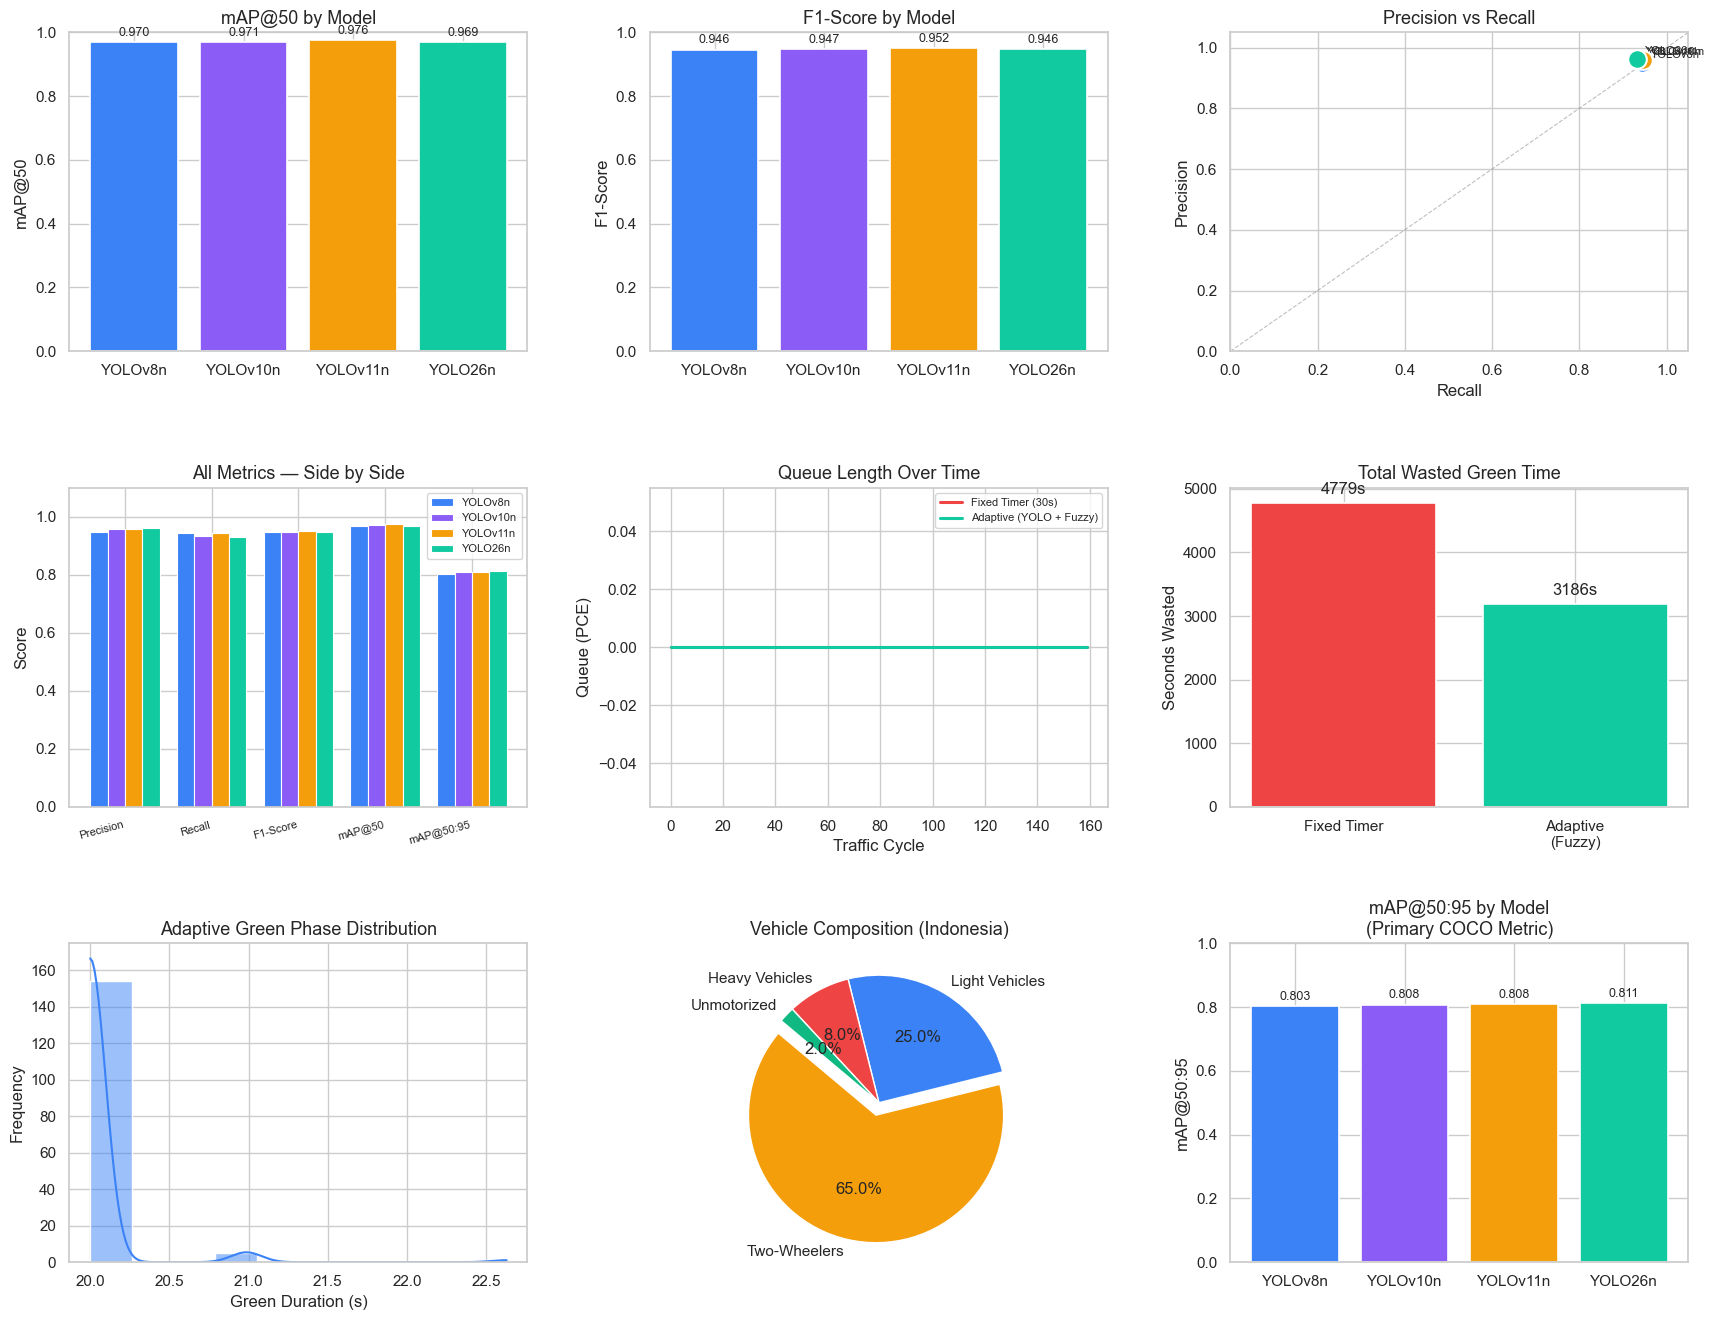


✅ Grafik tersimpan di '/kaggle/working/traffic_model_comparison.png'


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

# ── Pull data from earlier cells ─────────────────────────────────────────────
cycles         = range(len(adaptive))
adaptive_queue = [r['queue_remaining'] for r in adaptive]
fixed_queue    = [r['queue_remaining'] for r in fixed]
adaptive_waste = sum(r['wasted_green'] for r in adaptive)
fixed_waste    = sum(r['wasted_green'] for r in fixed)
adaptive_green_times = [r['green'] for r in adaptive]

# Model comparison dataframe
df_cmp = pd.DataFrame(comparison_results).T if comparison_results else pd.DataFrame()

# Color configuration mapped cleanly for 4 models
MODEL_COLORS = {
    'YOLOv8n':  '#3b82f6',
    'YOLOv10n': '#8b5cf6',
    'YOLOv11n': '#f59e0b',
    'YOLO26n':  '#11caa0',
}

fig = plt.figure(figsize=(18, 14))

# ── Plot 1: mAP@50 bar comparison ───────────────────────────────────────────
ax1 = plt.subplot(3, 3, 1)
if not df_cmp.empty:
    models_list = df_cmp.index.tolist()
    colors_list = [MODEL_COLORS.get(m, '#94a3b8') for m in models_list]
    bars = ax1.bar(models_list, df_cmp['mAP@50'], color=colors_list, edgecolor='white', linewidth=1.2)
    ax1.set_title('mAP@50 by Model', fontsize=13, fontweight='bold')
    ax1.set_ylabel('mAP@50')
    ax1.set_ylim(0, 1.0)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('mAP@50 by Model', fontsize=13, fontweight='bold')

# ── Plot 2: F1-Score bar comparison ─────────────────────────────────────────
ax2 = plt.subplot(3, 3, 2)
if not df_cmp.empty:
    bars2 = ax2.bar(models_list, df_cmp['F1-Score'], color=colors_list, edgecolor='white', linewidth=1.2)
    ax2.set_title('F1-Score by Model', fontsize=13, fontweight='bold')
    ax2.set_ylabel('F1-Score')
    ax2.set_ylim(0, 1.0)
    for bar in bars2:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('F1-Score by Model', fontsize=13, fontweight='bold')

# ── Plot 3: Precision vs Recall scatter ─────────────────────────────────────
ax3 = plt.subplot(3, 3, 3)
if not df_cmp.empty:
    for m in models_list:
        ax3.scatter(df_cmp.loc[m, 'Recall'], df_cmp.loc[m, 'Precision'],
                    s=180, color=MODEL_COLORS.get(m, '#94a3b8'), label=m, zorder=5, edgecolors='white', linewidths=1.5)
        ax3.annotate(m, (df_cmp.loc[m, 'Recall'], df_cmp.loc[m, 'Precision']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8, fontweight='bold')
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_xlim(0, 1.05)
    ax3.set_ylim(0, 1.05)
    ax3.axline((0, 0), slope=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax3.set_title('Precision vs Recall', fontsize=13, fontweight='bold')

# ── Plot 4: Full metrics grouped bar ────────────────────────────────────────
ax4 = plt.subplot(3, 3, 4)
if not df_cmp.empty:
    metric_cols = ['Precision', 'Recall', 'F1-Score', 'mAP@50', 'mAP@50:95']
    x = np.arange(len(metric_cols))
    n_models = len(models_list)
    width = 0.8 / n_models
    for i, m in enumerate(models_list):
        vals = [df_cmp.loc[m, c] for c in metric_cols]
        offset = (i - (n_models - 1) / 2) * width
        ax4.bar(x + offset, vals, width, label=m, color=MODEL_COLORS.get(m, '#94a3b8'),
                edgecolor='white', linewidth=0.8)
    ax4.set_xticks(x)
    ax4.set_xticklabels(metric_cols, fontsize=8, rotation=15, ha='right')
    ax4.set_ylim(0, 1.1)
    ax4.set_ylabel('Score')
    ax4.legend(fontsize=8)
ax4.set_title('All Metrics — Side by Side', fontsize=13, fontweight='bold')

# ── Plot 5: Queue length over time ──────────────────────────────────────────
ax5 = plt.subplot(3, 3, 5)
ax5.plot(cycles, fixed_queue,    label='Fixed Timer (30s)',       color='#ef4444', linewidth=2.2)
ax5.plot(cycles, adaptive_queue, label='Adaptive (YOLO + Fuzzy)', color='#11caa0', linewidth=2.2)
ax5.set_title('Queue Length Over Time', fontsize=13, fontweight='bold')
ax5.set_xlabel('Traffic Cycle')
ax5.set_ylabel('Queue (PCE)')
ax5.legend(fontsize=8)

# ── Plot 6: Wasted green time ────────────────────────────────────────────────
ax6 = plt.subplot(3, 3, 6)
bars6 = ax6.bar(['Fixed Timer', 'Adaptive\n(Fuzzy)'], [fixed_waste, adaptive_waste],
                color=['#ef4444', '#11caa0'], edgecolor='white', linewidth=1.2)
ax6.set_title('Total Wasted Green Time', fontsize=13, fontweight='bold')
ax6.set_ylabel('Seconds Wasted')
for bar in bars6:
    yval = bar.get_height()
    ax6.text(
        bar.get_x() + bar.get_width() / 2,
        yval + max(fixed_waste, adaptive_waste) * 0.02,
        f'{int(yval)}s',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# ── Plot 7: Adaptive green phase distribution ────────────────────────────────
ax7 = plt.subplot(3, 3, 7)
sns.histplot(adaptive_green_times, bins=10, kde=True, color='#3b82f6', ax=ax7)
ax7.set_title('Adaptive Green Phase Distribution', fontsize=13, fontweight='bold')
ax7.set_xlabel('Green Duration (s)')
ax7.set_ylabel('Frequency')

# ── Plot 8: Vehicle composition (Indonesian roads) ───────────────────────────
ax8 = plt.subplot(3, 3, 8)
labels_pie = ['Two-Wheelers', 'Light Vehicles', 'Heavy Vehicles', 'Unmotorized']
sizes_pie  = [65, 25, 8, 2]
colors_pie = ['#f59e0b', '#3b82f6', '#ef4444', '#10b981']
ax8.pie(sizes_pie, explode=(0.1, 0, 0, 0), labels=labels_pie, colors=colors_pie,
        autopct='%1.1f%%', startangle=140)
ax8.set_title('Vehicle Composition (Indonesia)', fontsize=13, fontweight='bold')

# ── Plot 9: mAP@50:95 comparison ────────────────────────────────────────────
ax9 = plt.subplot(3, 3, 9)
if not df_cmp.empty:
    bars9 = ax9.bar(models_list, df_cmp['mAP@50:95'], color=colors_list, edgecolor='white', linewidth=1.2)
    ax9.set_title('mAP@50:95 by Model\n(Primary COCO Metric)', fontsize=13, fontweight='bold')
    ax9.set_ylabel('mAP@50:95')
    ax9.set_ylim(0, 1.0)
    for bar in bars9:
        ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
else:
    ax9.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax9.transAxes)
    ax9.set_title('mAP@50:95 by Model', fontsize=13, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.savefig('/kaggle/working/traffic_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafik tersimpan di '/kaggle/working/traffic_model_comparison.png'")

In [ ]:
import time
import numpy as np
from ultralytics import YOLO

# Fix the dictionary to point to your actual trained weights
models_to_bench = {
    'YOLOv8n':  '/kaggle/working/runs/detect/traffic_yolov8n/weights/best.pt',
    'YOLOv10n': '/kaggle/working/runs/detect/traffic_yolov10n/weights/best.pt',
    'YOLOv11n': '/kaggle/working/runs/detect/traffic_yolov11n/weights/best.pt',
    'YOLO26n':  '/kaggle/working/runs/detect/traffic_yolo26n/weights/best.pt',
}

WARMUP   = 10
RUNS     = 100
IMG_SIZE = 640

# Use a real image from your dataset, or a dummy tensor
dummy = np.random.randint(0, 255, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

print(f"{'Model':<12} {'Avg (ms)':>10} {'FPS':>8} {'Params (M)':>12}")
print("=" * 46)

inference_results = {}
for name, weights in models_to_bench.items():
    model = YOLO(weights)
    model.to('cuda')

    # Warmup
    for _ in range(WARMUP):
        model(dummy, verbose=False)

    # Benchmark
    times = []
    for _ in range(RUNS):
        t0 = time.perf_counter()
        model(dummy, verbose=False)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)

    avg_ms = np.mean(times)
    fps    = 1000 / avg_ms
    params = sum(p.numel() for p in model.model.parameters()) / 1e6

    inference_results[name] = {
        'avg_ms': avg_ms,
        'fps':    fps,
        'params': params,
    }

    print(f"{name:<12} {avg_ms:>10.2f} {fps:>8.1f} {params:>12.2f}")

Model          Avg (ms)      FPS   Params (M)
YOLOv8n            8.66    115.5         3.01
YOLOv10n           9.89    101.1         2.27
YOLOv11n          10.21     97.9         2.58
YOLO26n           12.48     80.1         2.38
